Importing the Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and processing

In [20]:
# Loading the csv data to a pandas dataframe
gold_data = pd.read_csv('/content/gld_price_data[1].csv')

Printing first 5 rows

In [21]:
# print first 5 rows in the dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


Printing last 5 rows

In [22]:
# print last 5 rows of the dataframe
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


Printing no. of rows and columns

In [23]:
gold_data.shape

(2290, 6)

Getting some basic info

In [24]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


Checking the missing values

In [25]:
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


Getting statistical measures of data

In [26]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:-

1.) Positive correlation
2.) Negative correlation

In [27]:
gold_data = gold_data.drop(['Date'] , axis = 1)
correlation = gold_data.corr()

Constructing a heatmap

<Axes: >

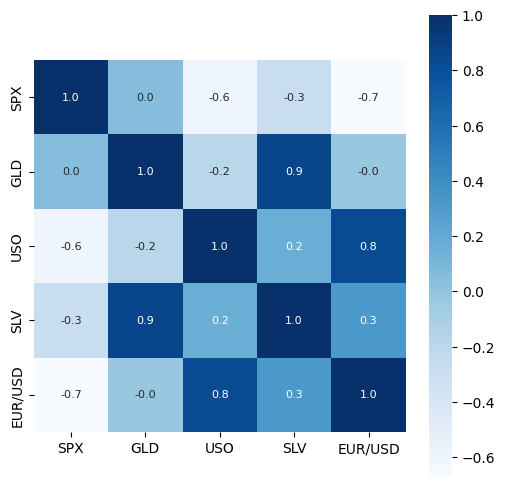

In [28]:
plt.figure(figsize = (6,6))
sns.heatmap(correlation , cbar = True , square = True , fmt = '.1f' , annot = True , annot_kws={'size':8} , cmap ='Blues')



Correlation values of GLD

In [29]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


Checking distribution of gold price

/tmp/ipykernel_238/1388081443.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'] , color = 'green')


<Axes: xlabel='GLD', ylabel='Density'>

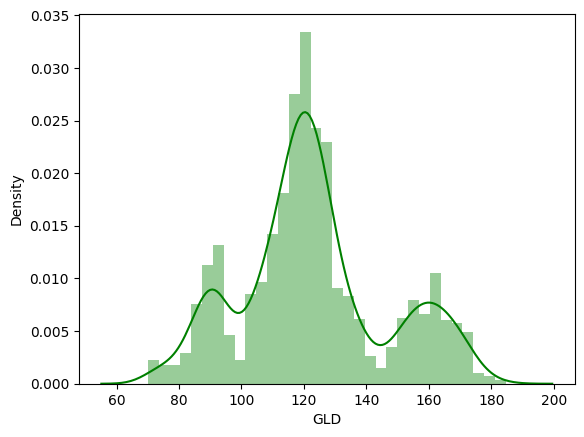

In [30]:
sns.distplot(gold_data['GLD'] , color = 'green')

Splitting the features and target

In [31]:
X = gold_data.drop(['GLD'] , axis = 1)
Y = gold_data['GLD']

In [32]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


Splitting into training and testing data

In [33]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 2)

Model Traing: Random Forest Regressor

In [34]:
regressor = RandomForestRegressor(n_estimators =100)

Training the model

In [35]:
regressor.fit(X_train , Y_train)

RandomForestRegressor()

Prediction on training data

In [36]:
test_data_prediction = regressor.predict(X_test)

In [37]:
print(test_data_prediction)

[168.48819918  81.81119992 116.02160015 127.58300075 120.82820152
 154.57229783 150.31559853 126.07880013 117.39159897 125.96020106
 117.0365008  172.1622009  141.73849829 167.80389889 115.19360013
 117.68710059 137.96320342 170.02330083 159.91920326 158.57999928
 155.16389996 125.36360008 176.19780011 157.09660297 125.24740068
  93.62999949  77.98260008 120.27010026 119.0858992  167.36099989
  87.98230043 125.22199975  91.12130076 117.64940031 121.04689953
 136.50400056 115.37170139 115.31460072 148.34049957 107.19300088
 104.17970266  87.19589781 126.48550047 118.00569995 154.44169905
 119.79649973 108.3616001  108.20089803  93.15520056 127.07829819
  75.0184004  113.59959921 121.24520068 111.307999   118.87849875
 120.82099953 159.94259913 168.18250138 147.12119719  85.94519846
  94.48820042  86.73109892  90.52470016 119.05760096 126.45520067
 127.27210009 169.43820006 122.22979928 117.35529917  98.39530049
 168.19810184 142.99839839 132.64030226 121.09150221 121.43339952
 119.56330

R squared error

In [38]:
error_score = metrics.r2_score(Y_test , test_data_prediction)
print("R squared error : " , error_score)

R squared error :  0.9887082172873704


Compare the predicted and actual values

In [39]:
Y_test = list(Y_test)

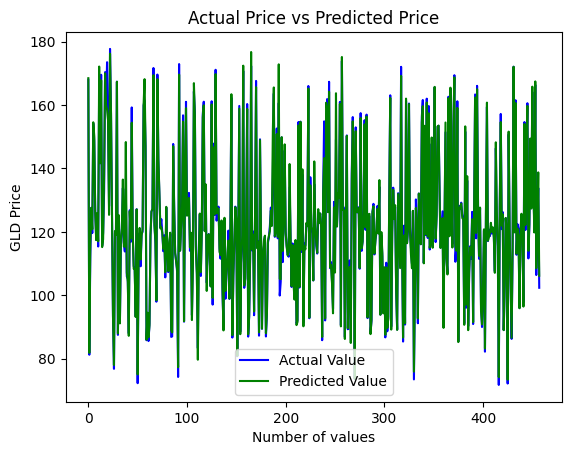

In [40]:
plt.plot(Y_test , color = 'blue' , label = 'Actual Value')
plt.plot(test_data_prediction , color = 'green' , label = 'Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()